In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, AveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [3]:
image_size = (64,64)

data_generator = ImageDataGenerator(rescale = 1/255, validation_split=0.2,
                                   width_shift_range = 0.1,    #horizontal_shift(-10% to +10%)
                                   height_shift_range = 0.1,    #vertical_shift(-10% to +10%)
                                   zoom_range = 0.15,     # zoomout(85%) to zoom in (115%)
                                    horizontal_flip = True,
                                    vertical_flip = False ,
                                    shear_range = 0.1   # -10% to +10%  tilt)
                                   )
                                    
train_generator = data_generator.flow_from_directory('animal_data/animal_data/', target_size=image_size,
                                                     batch_size=32,  subset = 'training')

val_generator = data_generator.flow_from_directory("animal_data/animal_data/", target_size = image_size,
                                                    batch_size = 32, subset = "validation")

Found 1561 images belonging to 15 classes.
Found 382 images belonging to 15 classes.


In [7]:
train_generator.class_indices.keys()

dict_keys(['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra'])

### Model Building

In [5]:
model = Sequential()
model.add(Conv2D(filters = 16,
         kernel_size = (3,3),
         activation = 'relu',
         input_shape = image_size + (3,)))

model.add(MaxPool2D(pool_size = (2, 2)))

model.add(Conv2D(filters = 32,
         kernel_size = (3,3),
         activation = 'relu'))

model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units = 64, activation = 'relu'))

model.add(Dense(units = 15, activation = 'softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,535 (1.55 MB)

 Trainable params: 407,535 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stopping = EarlyStopping(monitor = 'accuracy', patience = 5, verbose = 1)
model.compile(optimizer='adam', loss = 'categorical_crossentropy',metrics = ['accuracy'])
history = model.fit(train_generator, validation_data=val_generator, callbacks = early_stopping, epochs = 50, verbose = 2)

Epoch 1/50



KeyboardInterrupt



### Model Testing

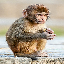

In [65]:
monkey = image.load_img("Monkey.jpg", target_size = image_size)
monkey

In [66]:
image_array = image.img_to_array(monkey)/255  #rescale pixel value 0 to 1
image_array

array([[[0.8117647 , 0.78431374, 0.70980394],
        [0.8156863 , 0.7882353 , 0.7137255 ],
        [0.8117647 , 0.7921569 , 0.7137255 ],
        ...,
        [0.80784315, 0.78039217, 0.7176471 ],
        [0.7921569 , 0.76862746, 0.7058824 ],
        [0.78431374, 0.7647059 , 0.6901961 ]],

       [[0.79607844, 0.7764706 , 0.69803923],
        [0.8       , 0.7882353 , 0.72156864],
        [0.80784315, 0.7882353 , 0.7137255 ],
        ...,
        [0.7921569 , 0.7607843 , 0.7176471 ],
        [0.79607844, 0.77254903, 0.7254902 ],
        [0.7882353 , 0.75686276, 0.7058824 ]],

       [[0.78431374, 0.75686276, 0.69411767],
        [0.8039216 , 0.7764706 , 0.7137255 ],
        [0.8039216 , 0.7764706 , 0.7137255 ],
        ...,
        [0.8       , 0.76862746, 0.7254902 ],
        [0.79607844, 0.7647059 , 0.72156864],
        [0.79607844, 0.7647059 , 0.72156864]],

       ...,

       [[0.5803922 , 0.5764706 , 0.49803922],
        [0.7372549 , 0.7529412 , 0.69411767],
        [0.78431374, 0

In [67]:
image_array.shape

(64, 64, 3)

In [68]:
test_array = image_array.reshape(1, 64, 64, 3)
test_array.shape

(1, 64, 64, 3)

In [75]:
list(model.predict(test_array)[0])
sorted(list(zip(list(train_generator.class_indices.keys()), list(model.predict(test_array)[0]))), key = lambda x:x[1])[-1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


('Tiger', np.float32(0.99637693))

In [76]:
len(list(train_generator.class_indices.keys())[1:])

14

In [81]:
def get_prediction(image_path):
    input_image = image.load_img(image_path, target_size = image_size)
    image_array = image.img_to_array(input_image)/255  
    test_array = image_array.reshape(1, 64, 64, 3)
    prediction = model.predict(test_array)
    output = sorted(list(zip(list(train_generator.class_indices.keys()), list(prediction[0]))), key = lambda x:x[1])[-1]

    return output

In [82]:
get_prediction("Monkey.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


('Tiger', np.float32(0.99637693))

In [83]:
get_prediction("Panda.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


('Panda', np.float32(0.9999896))

In [84]:
get_prediction("Tiger.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


('Zebra', np.float32(1.0))

In [86]:
get_prediction(r"C:\Users\Lenovo\Documents\Amisha\Jupyter Class files\Deep_Learning\CNN\CNN model Training & Deployment\animal_data\animal_data\Bear\bear_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


('Bear', np.float32(0.81699276))

In [87]:
get_prediction(r"C:\Users\Lenovo\Documents\Amisha\Jupyter Class files\Deep_Learning\CNN\CNN model Training & Deployment\animal_data\animal_data\Kangaroo\Kangaroo_1_2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


('Kangaroo', np.float32(0.99060655))

In [88]:
model.save('animal_prediction.keras')

In [ ]:
model = 